In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')
import scipy.stats as stats
from scipy.stats import ttest_ind 
import sqlite3

### Loading Dataset

In [11]:
cursor = conn.cursor()
cursor.execute("""SELECT name FROM sqlite_master WHERE type='table'; """)
tables = cursor.fetchall()
tables

[('begin_inventory',),
 ('end_inventory',),
 ('purchases',),
 ('purchase_prices',),
 ('sales',),
 ('vendor_invoice',),
 ('vendor_sales_summary',)]

In [5]:
conn = sqlite3.connect('inventory.db')
query = "SELECT * from vendor_sales_summary"
df = pd.read_sql_query(query,conn)
df.head(5)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,...,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,NetProfit,AvgBuyPrice,AvgSellPrice,PriceDifference,PriceDifferencePct
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,...,68601.68,1290667.91,25.297693,0.979108,1.338647,1222066.23,26.27,35.916617,9.646617,36.721039
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,...,144929.24,1015032.27,21.062810,0.976890,1.266830,870103.03,23.19,30.072784,6.882784,29.679967
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,...,123780.22,1119816.92,24.675786,0.998575,1.327594,996036.70,18.24,24.249870,6.009870,32.948847
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,...,257032.07,1214774.94,27.139908,0.993703,1.372493,957742.87,16.17,22.333857,6.163857,38.119089
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,...,257032.07,1199901.61,28.412764,0.983556,1.396897,942869.54,21.89,31.089295,9.199295,42.025102


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.000000e+00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,5.800000e+01,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,3.600000e-01,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,4.900000e-01,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,5.000000e+01,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.000000e+00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,7.100000e-01,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.000000e+00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.000000e+00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.000000e+00,289.710000,2857.800000,16059.562500,6.728193e+05


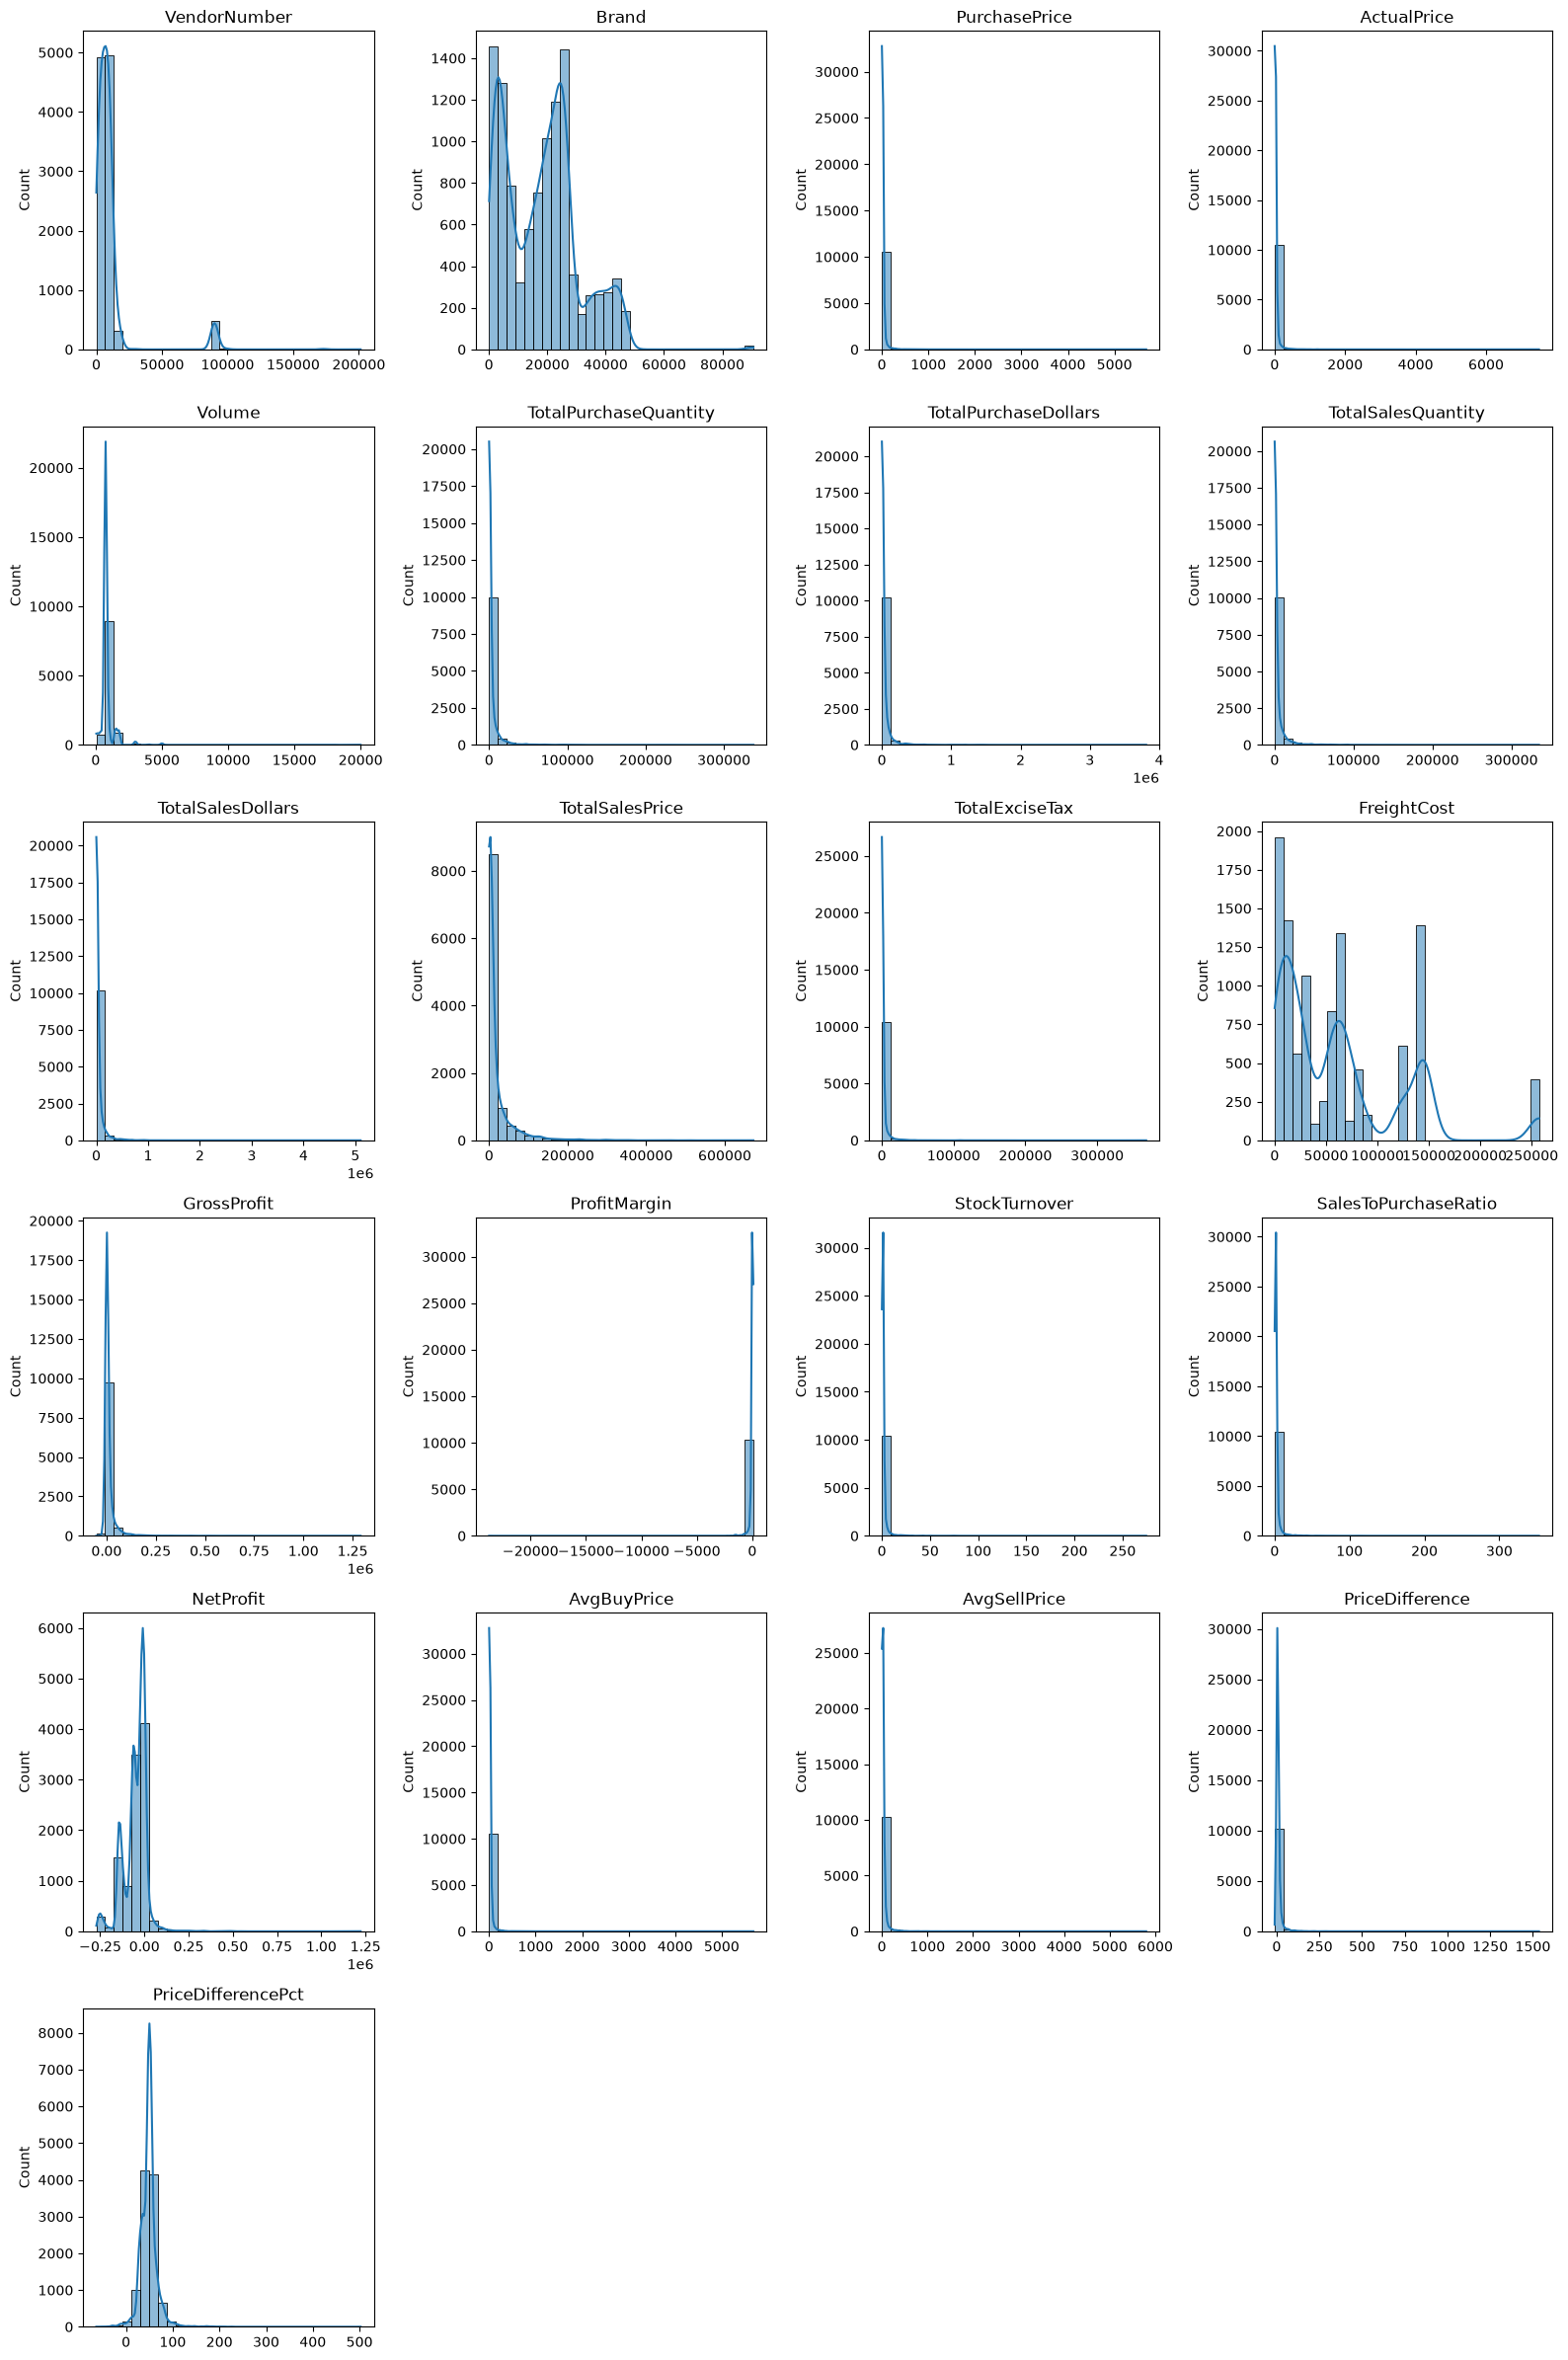

In [25]:
import math
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols

n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
    plt.xlabel("")

plt.tight_layout()
plt.show()

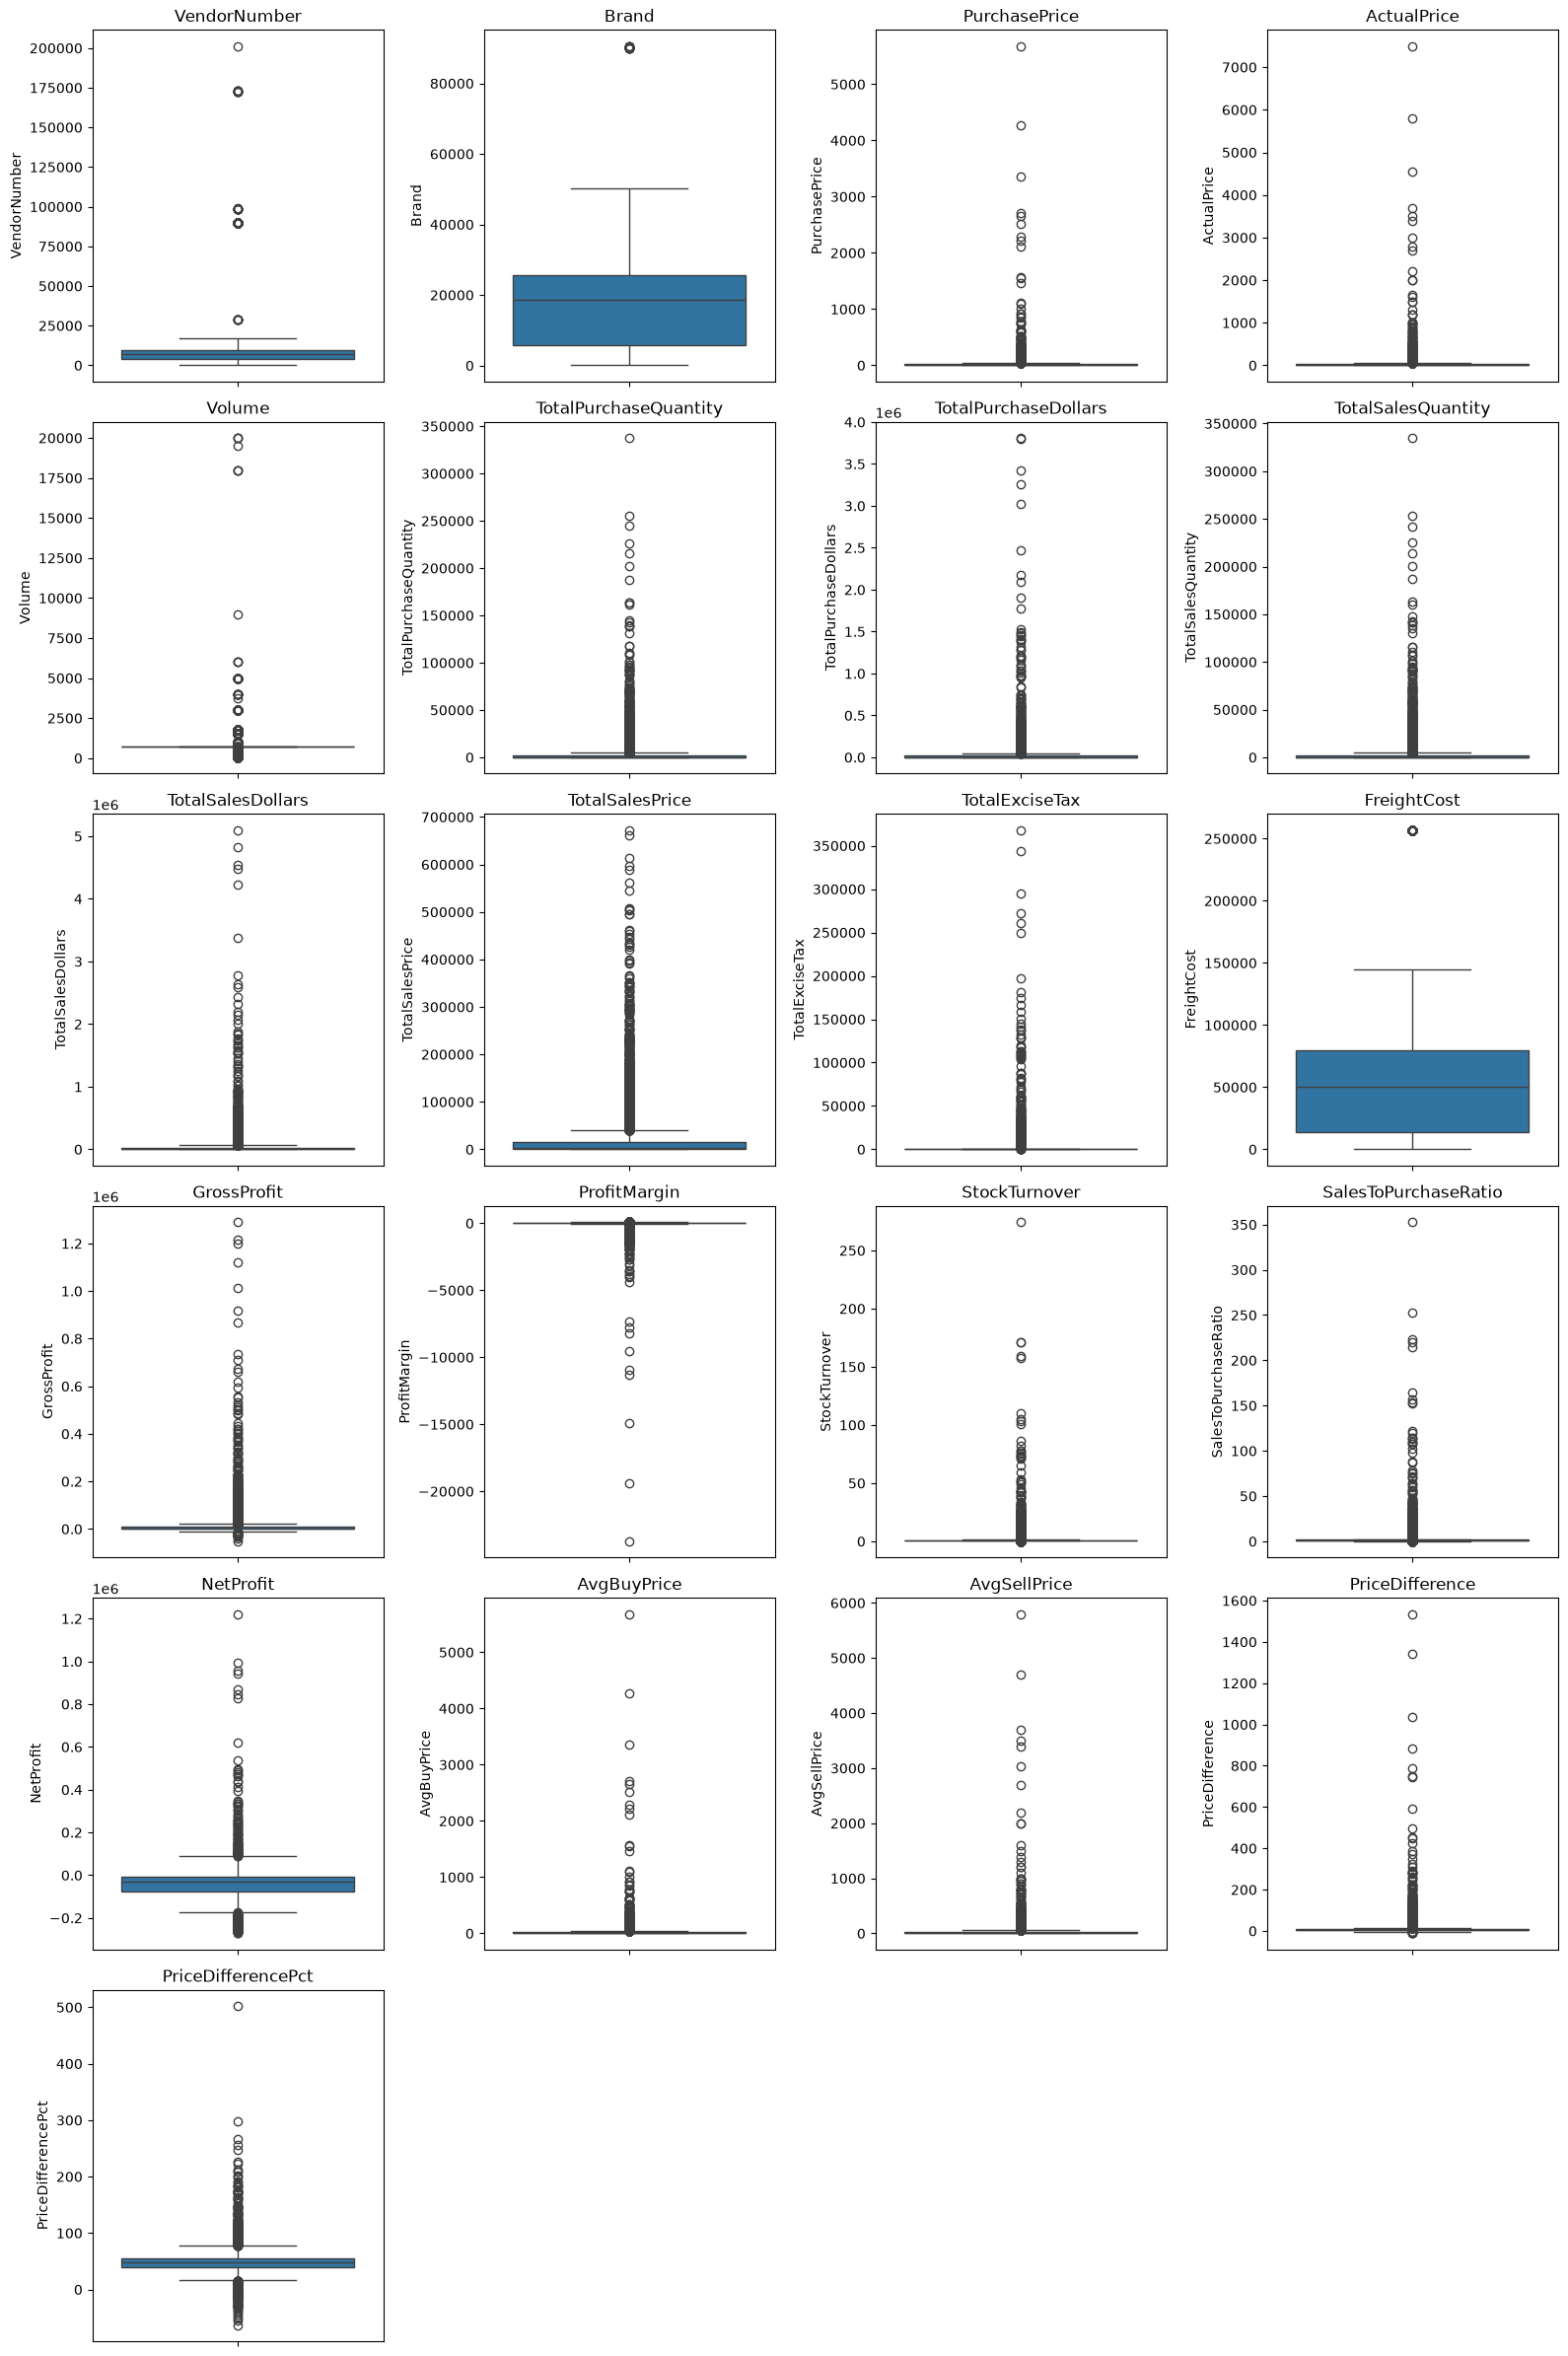

In [29]:
#Outlier Detection with box plots 
n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(df[col])
    plt.title(col)
    plt.xlabel("")

plt.tight_layout()
plt.show()

## Summary Statistics Insights:

### Negative & Zero Values:
- **Gross Profit:** Minimum value is **-52,002.78**, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
- **Profit Margin:** Has a minimum of **-∞**, which suggests cases where revenue is zero or even lower than costs.
- **Total Sales Quantity & Sales Dollars:** Minimum values are **0**, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

### Outliers Indicated by High Standard Deviations:
- **Purchase & Actual Prices:** The max values (**5,681.81 & 7,499.99**) are significantly higher than the mean (**24.39 & 35.64**), indicating potential premium products.
- **Freight Cost:** Huge variation, from **0.09 to 257,032.07**, suggests logistics inefficiencies or bulk shipments.
- **Stock Turnover:** Ranges from **0 to 274.5**, implying some products sell extremely fast while others remain in stock indefinitely. Values greater than **1** indicate sold quantity for that product is higher than purchased quantity due to either sales being fulfilled from older stock.

In [38]:
conn = sqlite3.connect('inventory.db')
query = """
SELECT * from vendor_sales_summary
WHERE GrossProfit>0
AND ProfitMargin>0 
AND TotalSalesQuantity>0
"""
df = pd.read_sql_query(query,conn)
df.sort_values(by='VendorNumber',ascending=True).head(5)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,...,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,NetProfit,AvgBuyPrice,AvgSellPrice,PriceDifference,PriceDifferencePct
7451,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750.0,8,190.88,18.0,...,27.08,474.94,71.331591,2.250000,3.488160,447.86,23.86,36.99,13.13,55.029338
6618,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750.0,39,446.16,47.0,...,367.52,258.37,36.672675,1.205128,1.579097,-109.15,11.44,14.99,3.55,31.031469
7087,105,ALTAMAR BRANDS LLC,2529,Right Gin,23.25,29.99,750.0,12,279.00,12.0,...,62.39,80.88,22.474158,1.000000,1.289892,18.49,23.25,29.99,6.74,28.989247
3252,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,750.0,320,11427.20,307.0,...,62.39,3919.73,25.540808,0.959375,1.343018,3857.34,35.71,49.99,14.28,39.988799
5913,200,AMERICAN SPIRITS EXCHANGE,20789,Zin-phomaniac Znfdl,9.73,14.99,750.0,96,934.08,84.0,...,6.19,577.08,38.187882,0.875000,1.617806,570.89,9.73,17.99,8.26,84.892086


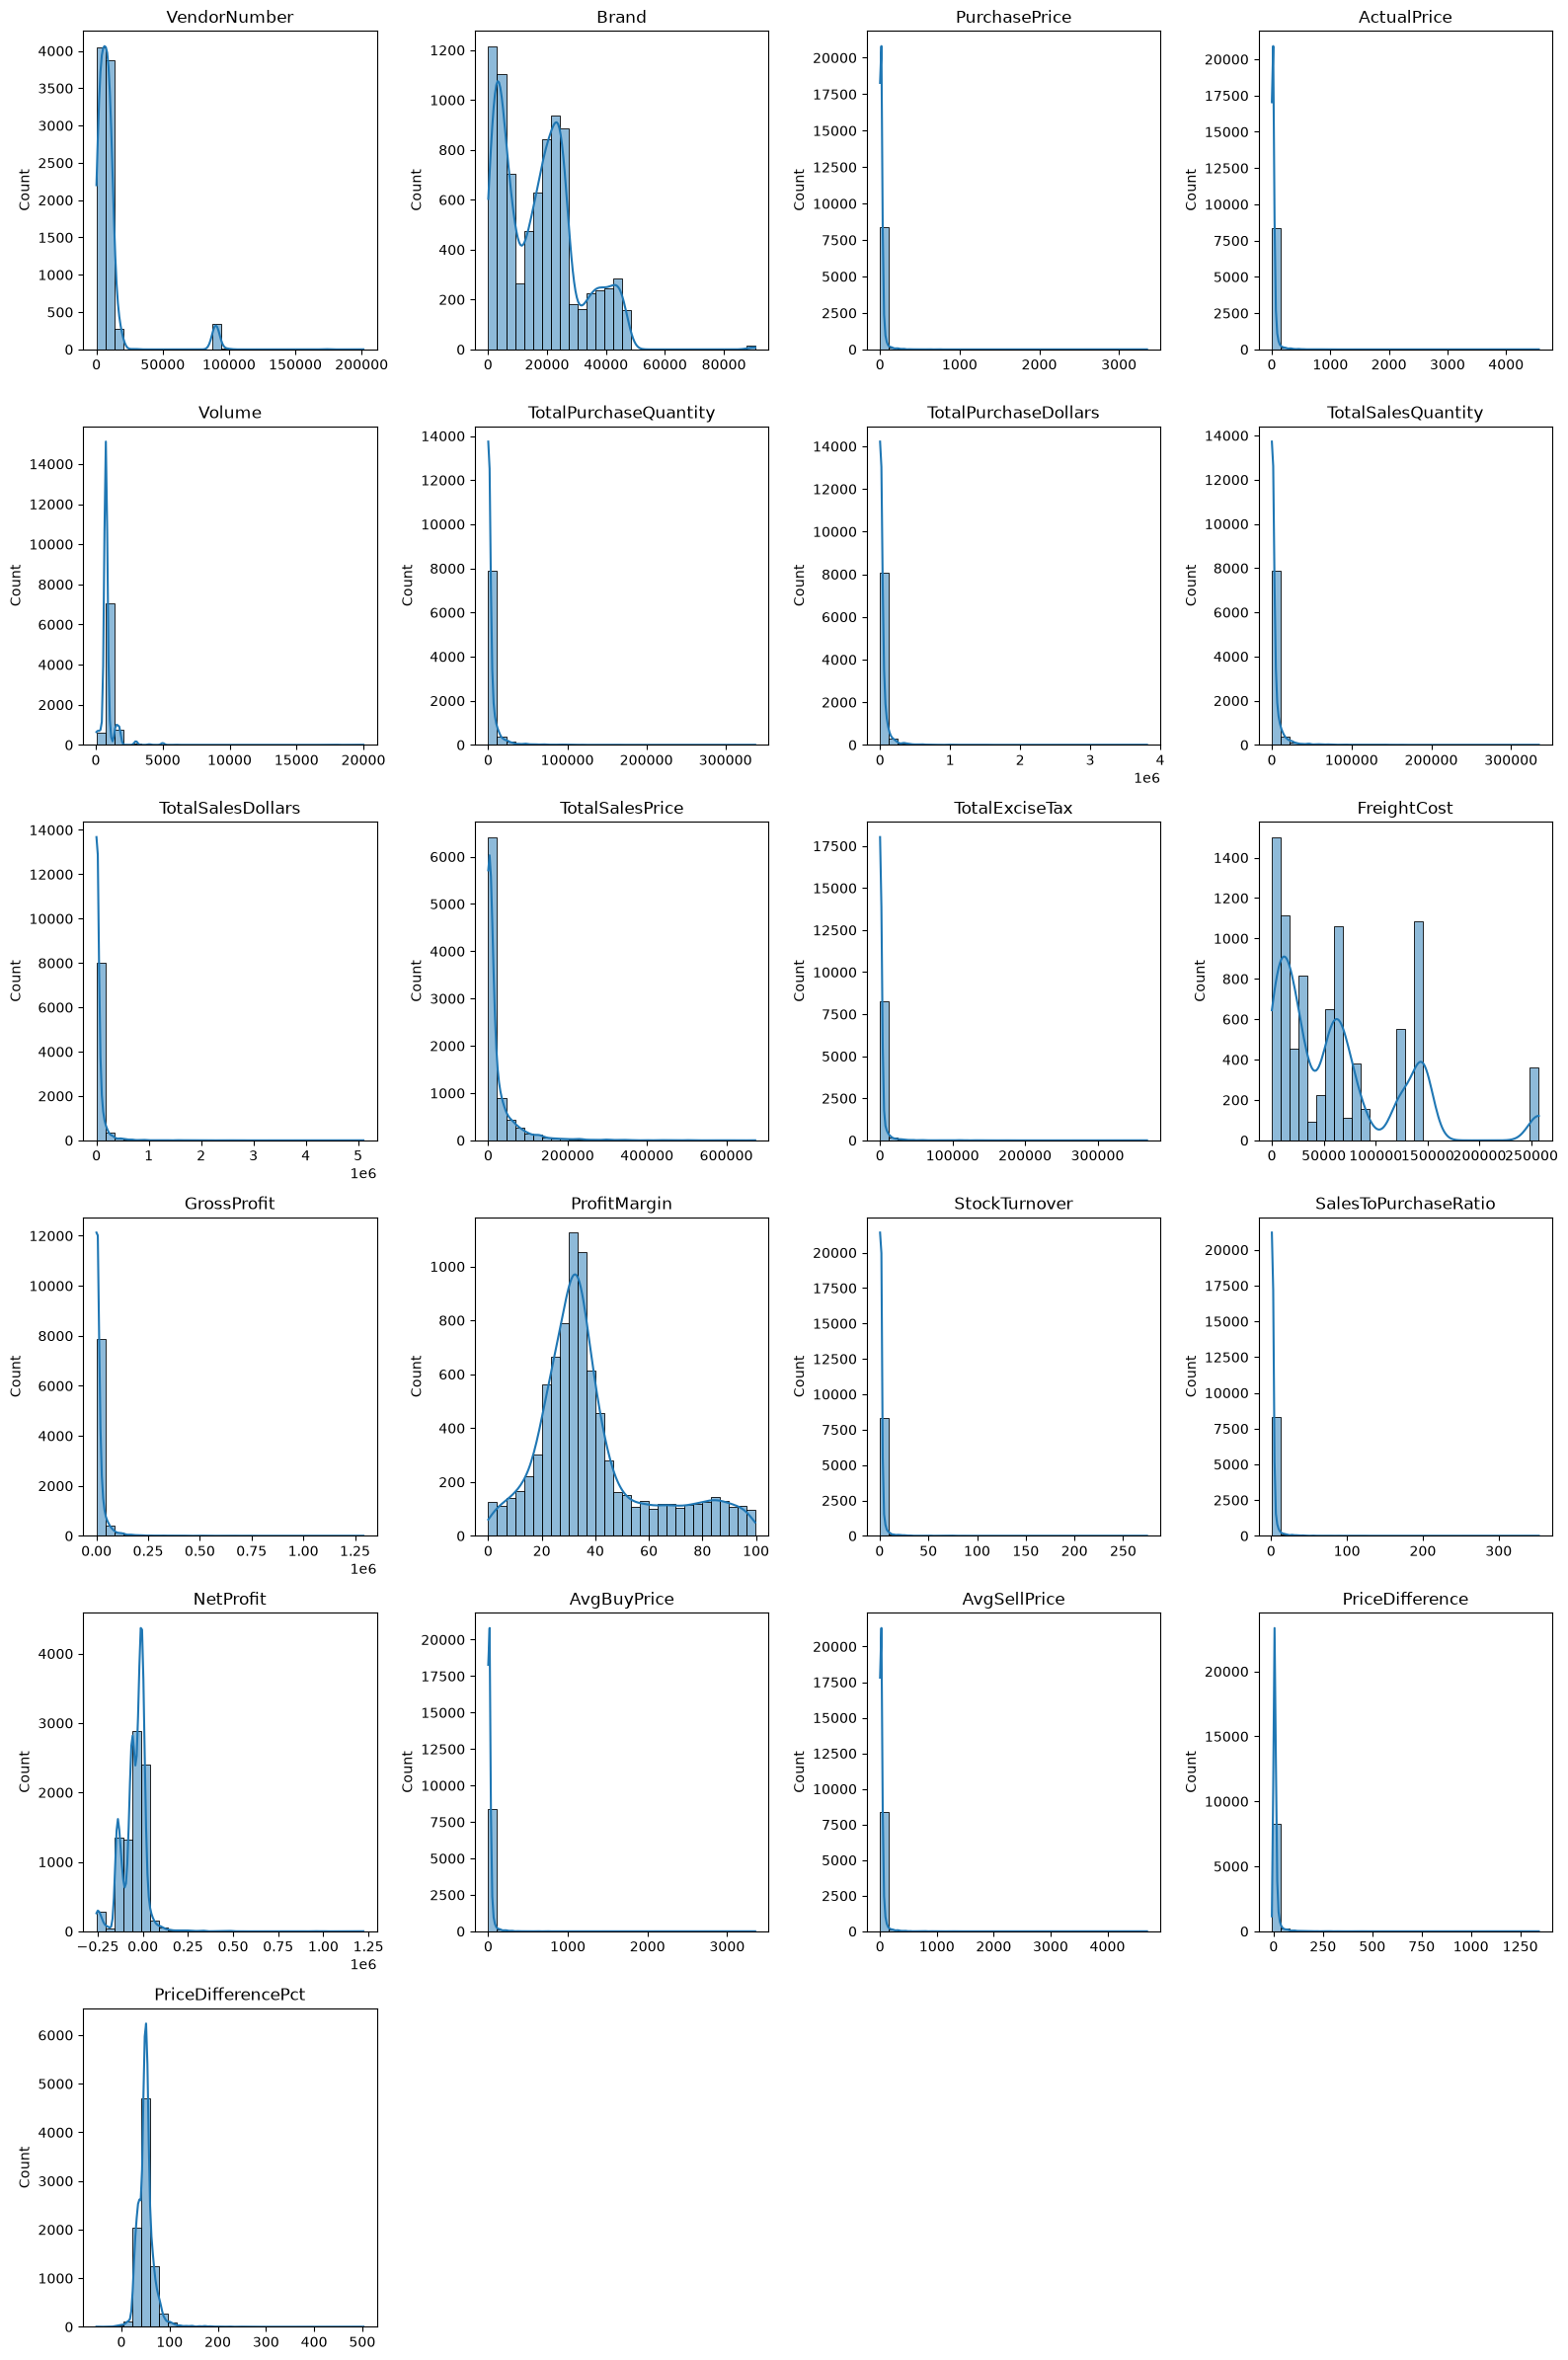

In [41]:
import math
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols

n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
    plt.xlabel("")

plt.tight_layout()
plt.show()

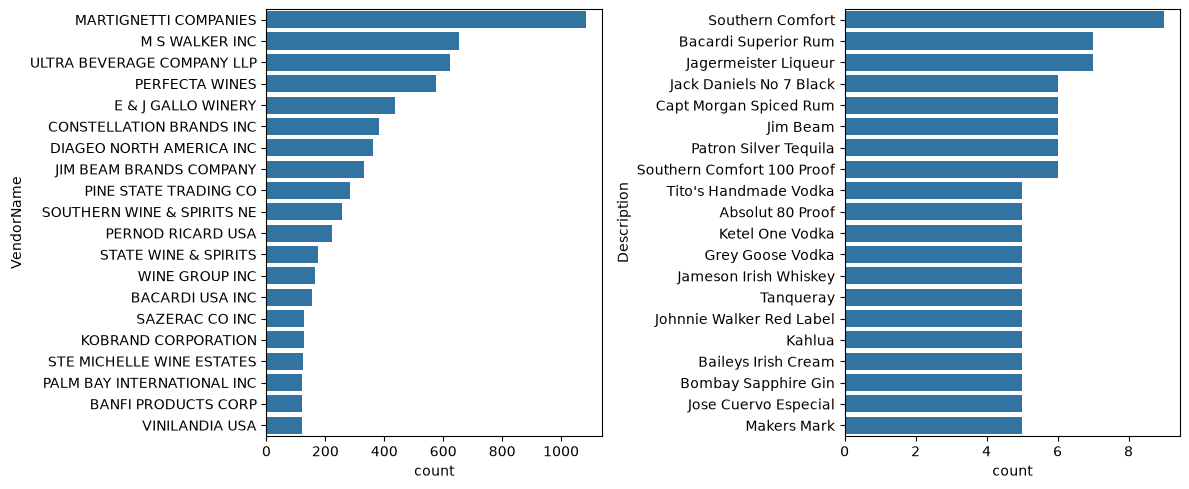

In [52]:
categorical_cols = df.select_dtypes(exclude=np.number).columns

plt.figure(figsize=(12,5))
for i,col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:20])
plt.tight_layout()
plt.show()

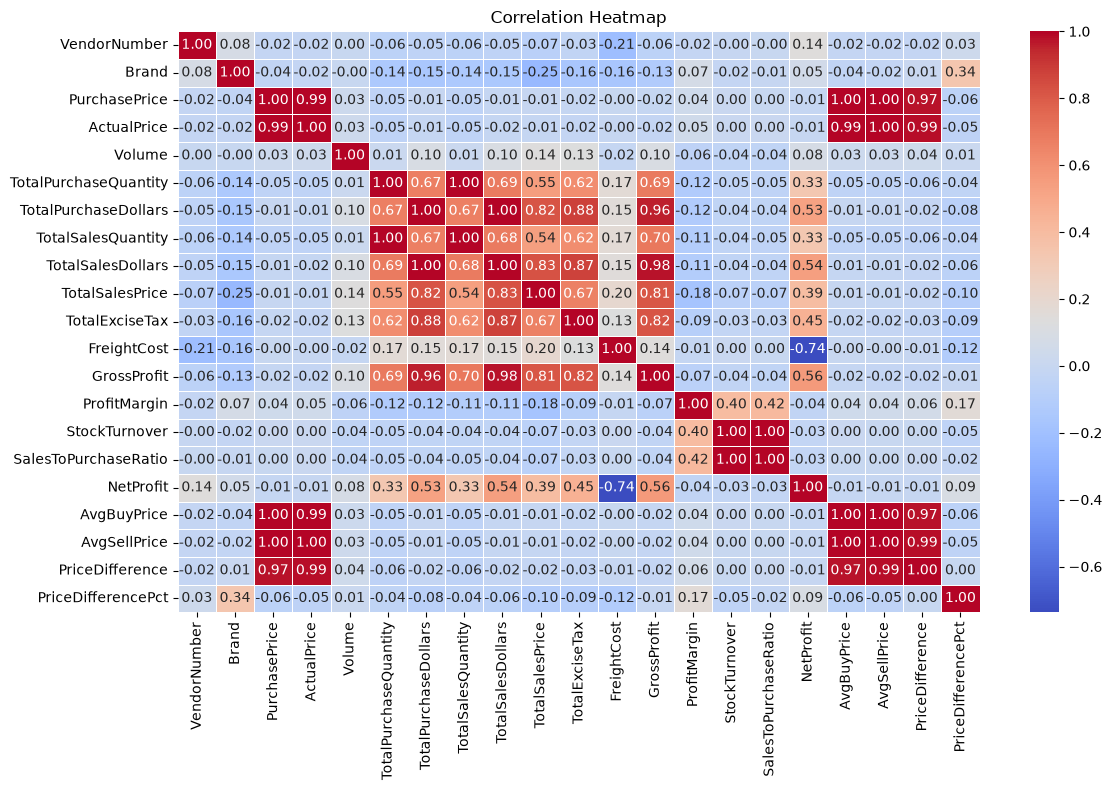

In [58]:
plt.figure(figsize=(12,8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## Correlation Insights

- **PurchasePrice** has weak correlations with **TotalSalesDollars (-0.012)** and **GrossProfit (-0.016)**, suggesting that price variations do not significantly impact sales revenue or profit.
- Strong correlation between **Total Purchase Quantity** and **Total Sales Quantity (0.999)**, confirming efficient inventory turnover.
- Negative correlation between **Profit Margin** and **Total Sales Price (-0.179)** suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
- **StockTurnover** has weak negative correlations with both **GrossProfit (-0.038)** and **ProfitMargin (-0.055)**, indicating that faster turnover does not necessarily result in higher profitability.

## Data Analysis

**Identifying brands that need promotional or pricing adjustments which exhibit lower sales performance but higher profit margins**

In [88]:
brand_performance = df.groupby("Description").agg({
    "TotalSalesDollars": "sum",
    "ProfitMargin": "mean"
}).reset_index()

brand_performance.sort_values(by=['TotalSalesDollars','ProfitMargin'],ascending=False).reset_index()

,index,Description,TotalSalesDollars,ProfitMargin
0,3771,Jack Daniels No 7 Black,7964746.76,26.525491
1,7114,Tito's Handmade Vodka,7399657.58,28.953634
2,3402,Grey Goose Vodka,7209608.06,25.413817
3,1272,Capt Morgan Spiced Rum,6356320.62,27.261764
4,86,Absolut 80 Proof,6244752.03,27.051973
...,...,...,...,...
7702,178,Allen's Blue Curacao Liqueur,5.99,20.033389
7703,6488,Smirnoff Light Strawberry,5.94,50.168350
7704,2897,Firefly Ridge Chard,5.79,31.088083
7705,148,Albero Sparkling Wh Organic,5.79,28.497409


In [89]:
brand_performance.head(10)

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
5,10 Span Pnt Nr CC,2441.74,25.836084
6,12 Days of Pearls Gift Set,309.69,97.678323
7,13 Celsius Svgn Bl,34041.23,57.669978
8,13th Colony Sthrn Corn Whsky,359.82,42.446223
9,14 Hands Cab Svgn Wash,273570.44,38.227460


In [90]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [91]:
print(low_sales_threshold)

560.299


In [92]:
print(high_margin_threshold)

64.97017552750113


In [118]:
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars']<=low_sales_threshold) &
    (brand_performance['ProfitMargin']>=high_margin_threshold)
]
print(f"Brands with Low Sales but High Profit Margins")
display(target_brands.sort_values(by='TotalSalesDollars'))

Brands with Low Sales but High Profit Margins


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


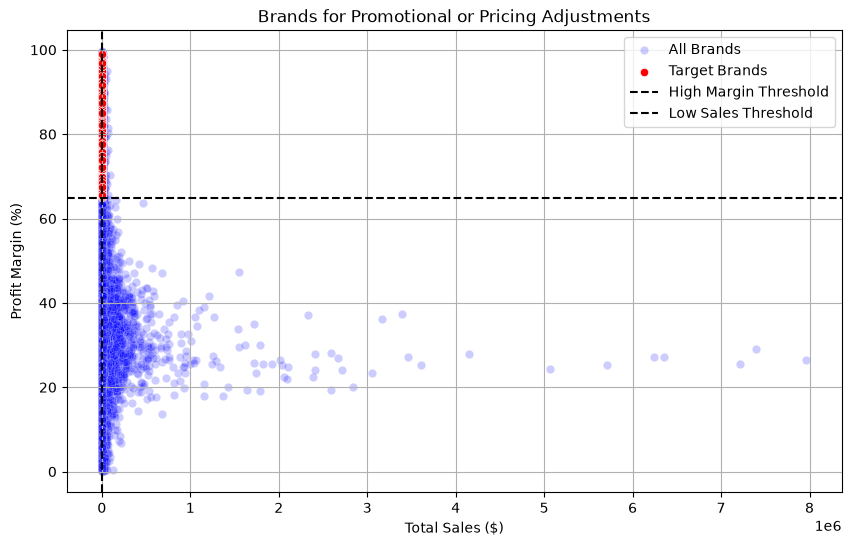

In [94]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance,
    x="TotalSalesDollars",
    y="ProfitMargin",
    color="blue",
    label="All Brands",
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x="TotalSalesDollars",
    y="ProfitMargin",
    color="red",
    label="Target Brands"
)

plt.axhline(
    high_margin_threshold,
    linestyle="--",
    color="black",
    label="High Margin Threshold"
)

plt.axvline(
    low_sales_threshold,
    linestyle="--",
    color="black",
    label="Low Sales Threshold"
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)

plt.show()

In [98]:
'''

import plotly.express as px
import plotly.graph_objects as go

# Base scatter plot
fig = px.scatter(
    brand_performance,
    x="TotalSalesDollars",
    y="ProfitMargin",
    hover_name="Description",
    opacity=0.2,
    color_discrete_sequence=["blue"],
    title="Brands for Promotional or Pricing Adjustments"
)
fig.data[0].name = "All Brands"

# Highlight target brands
fig.add_trace(
    go.Scatter(
        x=target_brands["TotalSalesDollars"],
        y=target_brands["ProfitMargin"],
        mode="markers",
        marker=dict(color="red", size=8),
        name="Target Brands"
    )
)

# Horizontal threshold line (Profit Margin)
fig.add_hline(
    y=high_margin_threshold,
    line_dash="dash",
    line_color="black",
    annotation_text="High Margin Threshold"
)

# Vertical threshold line (Sales)
fig.add_vline(
    x=low_sales_threshold,
    line_dash="dash",
    line_color="black",
    annotation_text="Low Sales Threshold"
)

fig.update_layout(
    template="plotly_white",
    width=900,
    height=600,
    legend_title=""
)

fig.show() '''

'\n\nimport plotly.express as px\nimport plotly.graph_objects as go\n\n# Base scatter plot\nfig = px.scatter(\n    brand_performance,\n    x="TotalSalesDollars",\n    y="ProfitMargin",\n    hover_name="Description",\n    opacity=0.2,\n    color_discrete_sequence=["blue"],\n    title="Brands for Promotional or Pricing Adjustments"\n)\nfig.data[0].name = "All Brands"\n\n# Highlight target brands\nfig.add_trace(\n    go.Scatter(\n        x=target_brands["TotalSalesDollars"],\n        y=target_brands["ProfitMargin"],\n        mode="markers",\n        marker=dict(color="red", size=8),\n        name="Target Brands"\n    )\n)\n\n# Horizontal threshold line (Profit Margin)\nfig.add_hline(\n    y=high_margin_threshold,\n    line_dash="dash",\n    line_color="black",\n    annotation_text="High Margin Threshold"\n)\n\n# Vertical threshold line (Sales)\nfig.add_vline(\n    x=low_sales_threshold,\n    line_dash="dash",\n    line_color="black",\n    annotation_text="Low Sales Threshold"\n)\n\nfig.up

#### Which vendors and brands demonstrate the highest sales performance ?

In [107]:
def format_dollars(value):
    if value >= 1_000_000: return f"{value/1_000_000:.2f}M"
    elif value >= 1_000: return f"{value/1_000:.2f}K"
    else: return value

In [119]:
top_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)

In [125]:
display(top_vendors.apply(format_dollars))
print(f"\n")
display(top_brands.apply(format_dollars))

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesDollars, dtype: str

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: str

In [126]:
display(top_vendors)

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [113]:
display(top_brands)

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: str

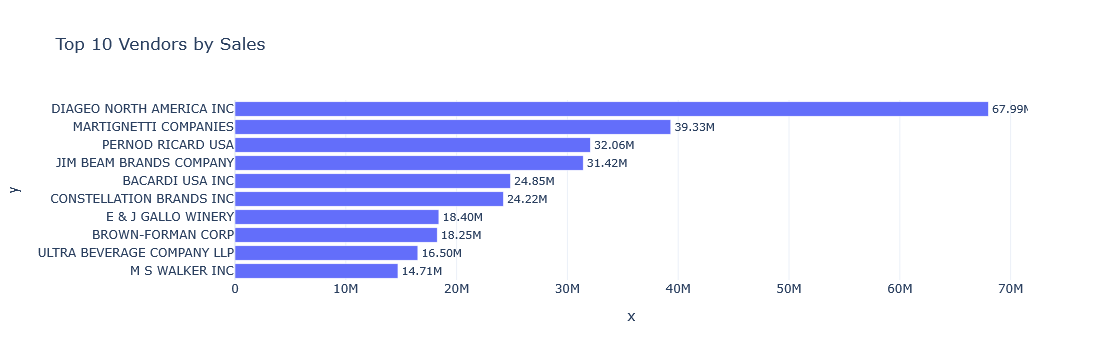

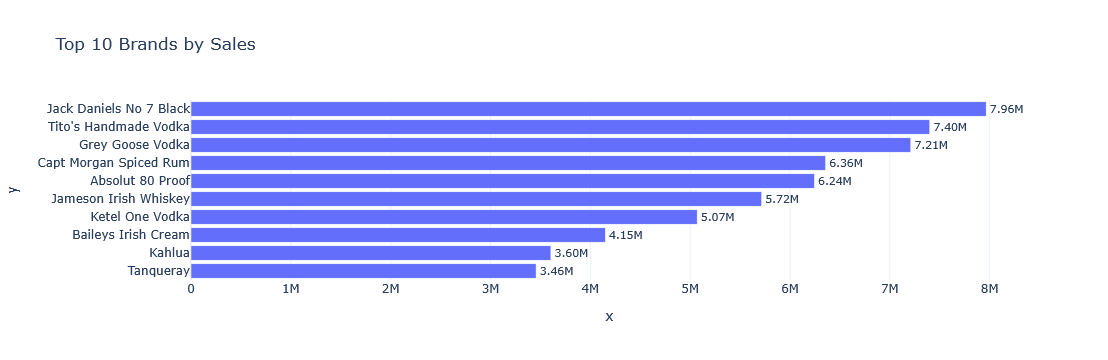

In [134]:
import plotly.express as px

fig = px.bar(
    x=top_vendors.values,
    y=top_vendors.index,
    orientation="h",
    text=[format_dollars(x) for x in top_vendors.values],
    title="Top 10 Vendors by Sales"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    template="plotly_white",
    yaxis=dict(autorange="reversed")
)

fig.show()
fig = px.bar(
    x=top_brands.values,
    y=top_brands.index[:10].astype(str),
    orientation="h",
    text=[format_dollars(x) for x in top_brands.values],
    title="Top 10 Brands by Sales"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    template="plotly_white",
    yaxis=dict(autorange="reversed")
)

fig.show()

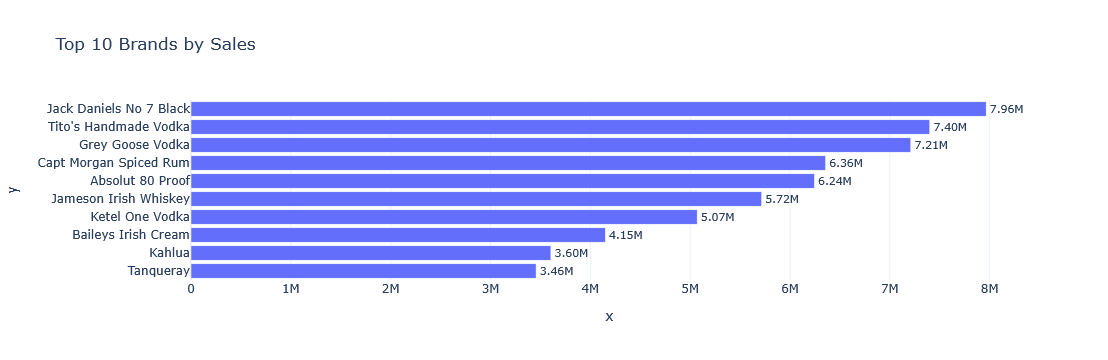

In [136]:
fig = px.bar(
    x=top_brands.values,
    y=top_brands.index.astype(str)[:10],
    orientation="h",
    text=[format_dollars(x) for x in top_brands.values],
    title="Top 10 Brands by Sales"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    template="plotly_white",
    yaxis=dict(autorange="reversed")
)

fig.show()

#### Which vendors contribute the most to the total purchase dollars ?

In [243]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

vendor_performance['PurchaseDollarsContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()

In [244]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseDollarsContribution%
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53,0.000001
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94,0.000084
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81,0.000038
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16,0.000003
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53,0.000340
...,...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13,0.000139
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83,0.000971
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20,0.019121
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28,0.016932


In [247]:
vendor_performance_sorted =round(vendor_performance.sort_values(by=["PurchaseDollarsContribution%"],ascending=False),2)

In [248]:
vendor_performance_sorted

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseDollarsContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,0.16
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,0.08
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,0.08
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,0.08
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,0.06
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
107,UNCORKED,118.74,58.20,176.94,0.00
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


In [249]:
for col in vendor_performance_sorted.columns[1:4]:
    vendor_performance_sorted[col]=vendor_performance_sorted[col].apply(format_dollars)

In [250]:
vendor_performance_sorted = vendor_performance_sorted.reset_index(drop=True)
vendor_performance_sorted.head(10)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseDollarsContribution%
0,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16
1,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.08
2,PERNOD RICARD USA,23.85M,8.21M,32.06M,0.08
3,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.08
4,BACARDI USA INC,17.43M,7.42M,24.85M,0.06
5,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05
6,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04
7,E & J GALLO WINERY,12.07M,6.33M,18.40M,0.04
8,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.04
9,M S WALKER INC,9.76M,4.94M,14.71M,0.03


In [251]:
top_vendors = (
    vendor_performance
    .nlargest(10, "PurchaseDollarsContribution%")
    .reset_index(drop=True)
)

In [252]:
print(f"Top 10 vendors contribute {round(top_vendors['PurchaseDollarsContribution%'].sum()*100,2)}% of the total Purchase in Dollars")
display(top_vendors)

Top 10 vendors contribute 65.69% of the total Purchase in Dollars


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseDollarsContribution%
0,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,0.163003
1,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,0.082977
2,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,0.077606
3,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,0.076444
4,BACARDI USA INC,17432020.26,7422796.88,24854817.14,0.056719
5,CONSTELLATION BRANDS INC,15273708.08,8945037.57,24218745.65,0.049697
6,BROWN-FORMAN CORP,13238939.18,5008291.47,18247230.65,0.043076
7,E & J GALLO WINERY,12068539.22,6331360.24,18399899.46,0.039268
8,ULTRA BEVERAGE COMPANY LLP,11167081.61,5335462.70,16502544.31,0.036335
9,M S WALKER INC,9764312.60,4942145.91,14706458.51,0.031771


In [253]:
top_vendors['CumulativeContribution%'] = top_vendors['PurchaseDollarsContribution%'].cumsum()

In [254]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseDollarsContribution%,CumulativeContribution%
0,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,0.163003,0.163003
1,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,0.082977,0.245981
2,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,0.077606,0.323586
3,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,0.076444,0.400031
4,BACARDI USA INC,17432020.26,7422796.88,24854817.14,0.056719,0.456750
5,CONSTELLATION BRANDS INC,15273708.08,8945037.57,24218745.65,0.049697,0.506447
6,BROWN-FORMAN CORP,13238939.18,5008291.47,18247230.65,0.043076,0.549523
7,E & J GALLO WINERY,12068539.22,6331360.24,18399899.46,0.039268,0.588791
8,ULTRA BEVERAGE COMPANY LLP,11167081.61,5335462.70,16502544.31,0.036335,0.625125
9,M S WALKER INC,9764312.60,4942145.91,14706458.51,0.031771,0.656896


In [255]:

top_vendors['CumulativeContribution%'] = round(top_vendors['CumulativeContribution%']*100,2) 

In [257]:
top_vendors['PurchaseDollarsContribution%'] = round(top_vendors['PurchaseDollarsContribution%']*100,2)

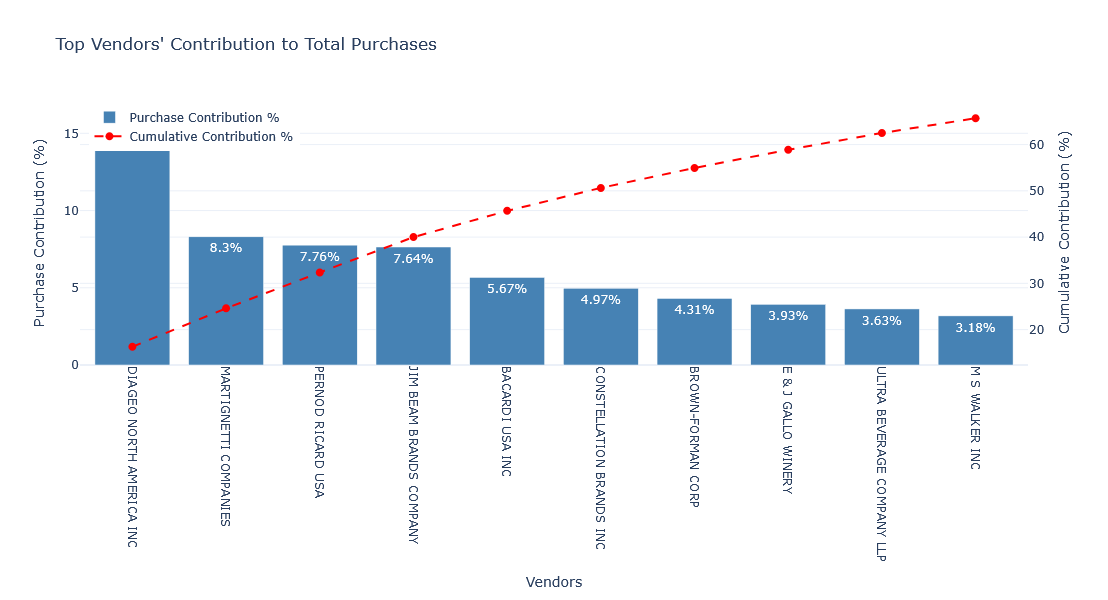

In [261]:
import plotly.graph_objects as go

# Cumulative contribution
top_vendors["Cumulative_Contribution%"] = (
    top_vendors["PurchaseDollarsContribution%"].cumsum() * 100
)

fig = go.Figure()

# Bar chart
fig.add_trace(
    go.Bar(
        x=top_vendors["VendorName"],
        y=top_vendors["PurchaseDollarsContribution%"] ,
        name="Purchase Contribution %",
        text=(top_vendors["PurchaseDollarsContribution%"]).round(2).astype(str) + "%",
        textposition="inside",
        marker_color="steelblue",
        yaxis="y"
    )
)

# Cumulative line
fig.add_trace(
    go.Scatter(
        x=top_vendors["VendorName"],
        y=top_vendors["CumulativeContribution%"],
        mode="lines+markers",
        name="Cumulative Contribution %",
        line=dict(color="red", dash="dash"),
        marker=dict(size=8),
        yaxis="y2"
    )
)

fig.update_layout(
    title="Top Vendors' Contribution to Total Purchases",
    template="plotly_white",
    xaxis=dict(title="Vendors", tickangle=90),
    yaxis=dict(
        title="Purchase Contribution (%)",
        side="left"
    ),
    yaxis2=dict(
        title="Cumulative Contribution (%)",
        overlaying="y",
        side="right"
    ),
    legend=dict(x=0.01, y=0.99),
    width=1000,
    height=600
)

fig.show()

#### How much of total procurement is dependent on the top vednors 


In [267]:
print(f"Total Contribution of the top 10 vendors is {round(top_vendors['PurchaseDollarsContribution%'].sum(),2)}%")

Total Contribution of the top 10 vendors is 65.69%


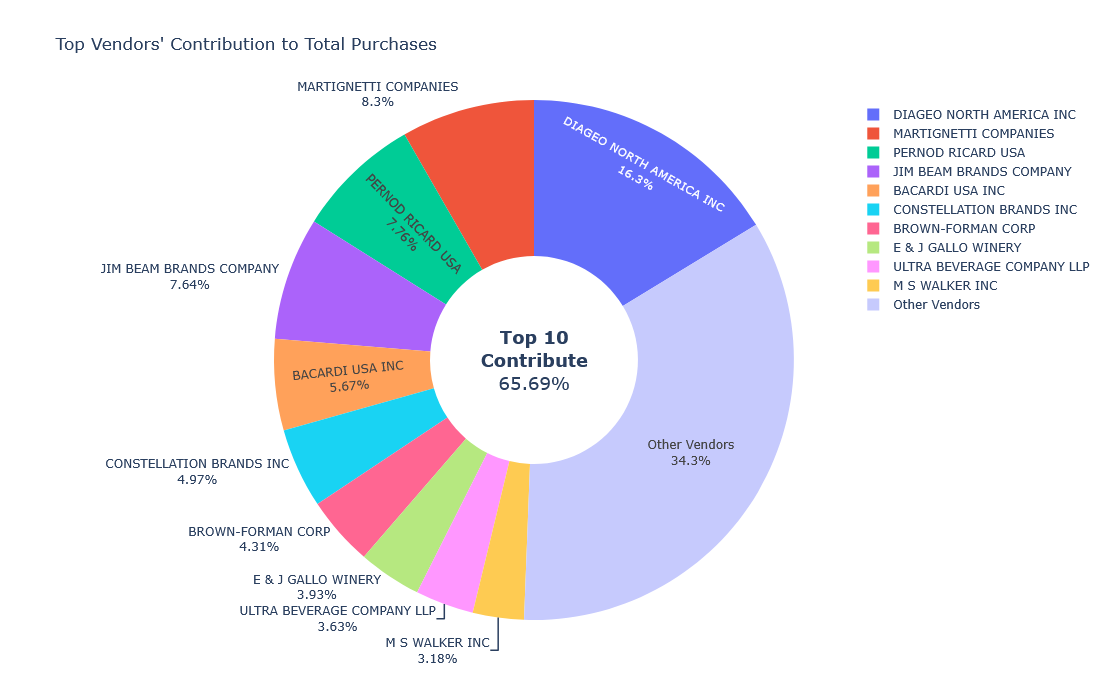

In [275]:
import plotly.graph_objects as go

vendors = top_vendors["VendorName"].tolist()
purchase_contributions = (top_vendors["PurchaseDollarsContribution%"]).tolist()

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Add "Other Vendors"
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

fig = go.Figure(
    go.Pie(
        labels=vendors,
        values=purchase_contributions,
        hole=0.4,
        textinfo="percent+label",
        textposition="auto",
        sort=False
    )
)

# Text in the center
fig.add_annotation(
    text=f"<b>Top 10<br> Contribute </b><br>{total_contribution:.2f}%",
    x=0.5,
    y=0.5,
    showarrow=False,
    font=dict(size=18)
)

fig.update_layout(
    title="Top Vendors' Contribution to Total Purchases",
    template="plotly_white",
    width=800,
    height=700
)

fig.show()

#### Does Purchasing in Bulk reduce the unit price and what is the optimal purchase volume for the cost savings ?

In [312]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [313]:
df["OrderSize"] = pd.qcut(
    df["TotalPurchaseQuantity"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

In [314]:
new_order = ['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity','Unit Purchase Price', 'OrderSize', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio', 'NetProfit',
       'AvgBuyPrice', 'AvgSellPrice', 'PriceDifference', 'PriceDifferencePct']

df = df.reindex(columns=new_order)

In [315]:
pd.set_option("display.max_columns", None)
display(df.head(10))
pd.reset_option("display.max_columns")

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,Unit Purchase Price,OrderSize,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,NetProfit,AvgBuyPrice,AvgSellPrice,PriceDifference,PriceDifferencePct
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,26.27,Very High,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,1222066.23,26.27,35.916617,9.646617,36.721039
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,23.19,Very High,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,870103.03,23.19,30.072784,6.882784,29.679967
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,18.24,Very High,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,996036.70,18.24,24.249870,6.009870,32.948847
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,16.17,Very High,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,957742.87,16.17,22.333857,6.163857,38.119089
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,21.89,Very High,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,942869.54,21.89,31.089295,9.199295,42.025102
5,480,BACARDI USA INC,3858,Grey Goose Vodka,17.77,23.99,750.0,138809,2466635.93,141860.0,17.77,Very High,3383912.40,446932.09,111699.19,89286.27,917276.47,27.106980,1.021980,1.371873,827990.20,17.77,23.853887,6.083887,34.236843
6,17035,PERNOD RICARD USA,2589,Jameson Irish Whiskey,30.76,39.99,1750.0,70783,2177285.08,69627.0,30.76,Very High,2773367.73,614529.34,127931.67,123780.22,596082.65,21.493098,0.983668,1.273773,472302.43,30.76,39.831786,9.071786,29.492151
7,3960,DIAGEO NORTH AMERICA INC,3102,Smirnoff Traveler,12.94,17.99,1750.0,161386,2088334.84,148265.0,12.94,Very High,2592041.35,292586.29,272422.60,257032.07,503706.51,19.432812,0.918698,1.241200,246674.44,12.94,17.482490,4.542490,35.104249
8,3960,DIAGEO NORTH AMERICA INC,3489,Tanqueray,20.73,27.99,1750.0,91835,1903739.55,90481.0,20.73,Very High,2640491.19,503661.02,166244.44,257032.07,736751.64,27.902068,0.985256,1.387002,479719.57,20.73,29.182825,8.452825,40.775808
9,12546,JIM BEAM BRANDS COMPANY,1376,Jim Beam,16.29,21.99,1750.0,108866,1773427.14,107061.0,16.29,Very High,2435393.39,426902.78,196707.35,123880.97,661966.25,27.181081,0.983420,1.373269,538085.28,16.29,22.747718,6.457718,39.642220


In [317]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'Unit Purchase Price',
       'OrderSize', 'TotalSalesDollars', 'TotalSalesPrice', 'TotalExciseTax',
       'FreightCost', 'GrossProfit', 'ProfitMargin', 'StockTurnover',
       'SalesToPurchaseRatio', 'NetProfit', 'AvgBuyPrice', 'AvgSellPrice',
       'PriceDifference', 'PriceDifferencePct'],
      dtype='str')

In [326]:
df.rename(columns={'Unit Purchase Price':'UnitPurchasePrice'},inplace=True)


In [329]:
round(df.groupby('OrderSize')[['UnitPurchasePrice']].mean(),2)

,UnitPurchasePrice
OrderSize,
Very Low,51.11
Low,19.31
Moderate,15.47
High,13.18
Very High,9.67


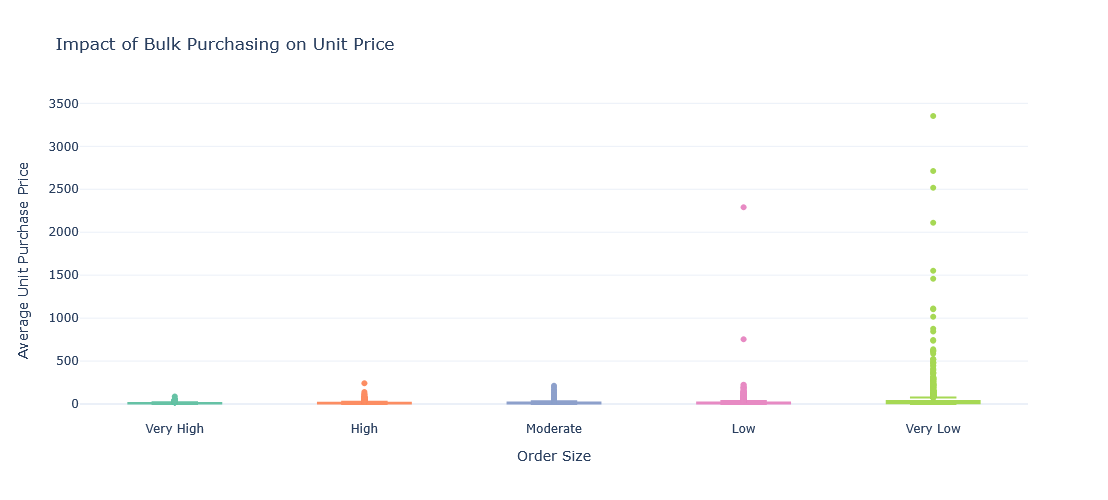

In [333]:
import plotly.express as px

fig = px.box(
    df,
    x="OrderSize",
    y="UnitPurchasePrice",
    color="OrderSize",
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="Impact of Bulk Purchasing on Unit Price",
    labels={
        "OrderSize": "Order Size",
        "UnitPurchasePrice": "Average Unit Purchase Price"
    },
    points="outliers"   # Options: "all", "outliers", False
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Order Size",
    yaxis_title="Average Unit Purchase Price",
    showlegend=False,
    width=900,
    height=500
)

fig.show()

### Order Size vs. Unit Purchase Price Insights

- The **average unit purchase price decreases consistently as order size increases**, demonstrating a strong volume-based pricing strategy.
- **Very High** order sizes have the lowest average unit purchase price (**\$9.67 per unit**), while **Very Low** order sizes have the highest (**\$51.11 per unit**).
- The average unit purchase price decreases by approximately **81%**, from **$51.11** for **Very Low** orders to **\$9.67** for **Very High** orders, highlighting substantial bulk-purchase discounts.
- This trend suggests that suppliers encourage larger purchase volumes by offering lower per-unit prices, helping vendors reduce procurement costs and improve potential profit margins.
- The pricing structure reflects **economies of scale**, where larger purchase volumes result in lower unit costs and more efficient inventory procurement.

#### Which vendors have low inventory turnover indication excess stock and slow- moving inventory products ?

In [349]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values(by='StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


#### What is the 95% confidence intervals for profit margins of top performing and low performin vendors ?

In [393]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [394]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

In [395]:
from scipy import stats
import numpy as np

def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err

    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [396]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI : ({top_lower:.2f}, {top_upper:.2f})")
print(f"Top Vendors Mean   : {top_mean:.2f}\n")

print(f"Low Vendors 95% CI : ({low_lower:.2f}, {low_upper:.2f})")
print(f"Low Vendors Mean   : {low_mean:.2f}")

Top Vendors 95% CI : (30.74, 31.61)
Top Vendors Mean   : 31.18

Low Vendors 95% CI : (40.50, 42.64)
Low Vendors Mean   : 41.57


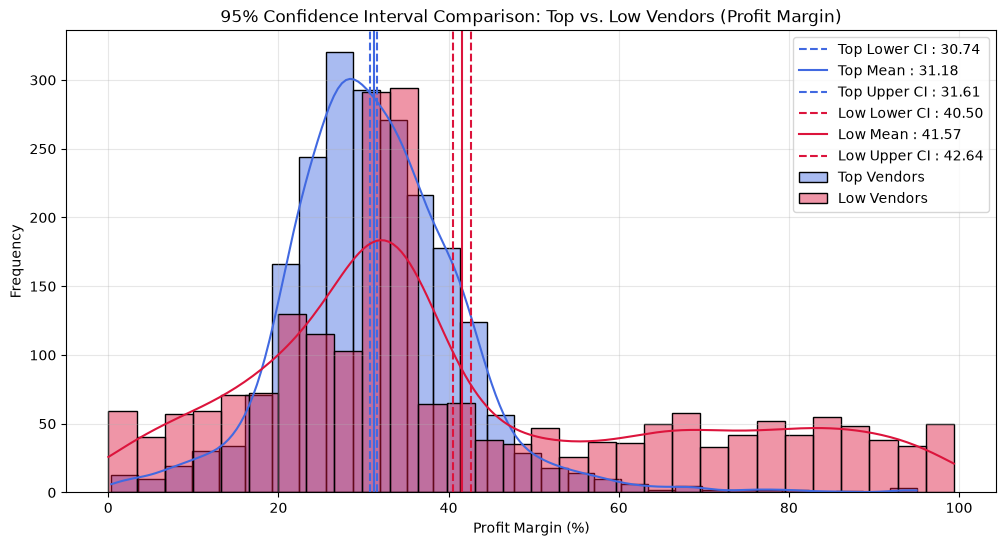

In [397]:
plt.figure(figsize=(12,6))

# Top Vendors
sns.histplot(
    top_vendors,
    kde=True,
    bins=30,
    color="royalblue",
    alpha=0.45,
    label="Top Vendors"
)

plt.axvline(top_lower, color="royalblue", linestyle="--",
            label=f"Top Lower CI : {top_lower:.2f}")

plt.axvline(top_mean, color="royalblue", linestyle="-",
            label=f"Top Mean : {top_mean:.2f}")

plt.axvline(top_upper, color="royalblue", linestyle="--",
            label=f"Top Upper CI : {top_upper:.2f}")

# Low Vendors
sns.histplot(
    low_vendors,
    kde=True,
    bins=30,
    color="crimson",
    alpha=0.45,
    label="Low Vendors"
)

plt.axvline(low_lower, color="crimson", linestyle="--",
            label=f"Low Lower CI : {low_lower:.2f}")

plt.axvline(low_mean, color="crimson", linestyle="-",
            label=f"Low Mean : {low_mean:.2f}")

plt.axvline(low_upper, color="crimson", linestyle="--",
            label=f"Low Upper CI : {low_upper:.2f}")

plt.title("95% Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")

plt.legend()
plt.grid(alpha=0.3)

plt.show()